OVERALL REVIEW LENGTH STATISTICS
count    19824.000000
mean       233.960452
std        174.343717
min         10.000000
25%        127.000000
50%        174.000000
75%        285.000000
max       2470.000000
Name: word_count, dtype: float64

REVIEW LENGTH BY SENTIMENT
        count        mean         std   min    25%    50%    75%     max
label                                                                   
0      9869.0  231.078934  167.538275  10.0  128.0  175.0  278.0  1522.0
1      9955.0  236.817077  180.800852  12.0  125.0  174.0  292.0  2470.0


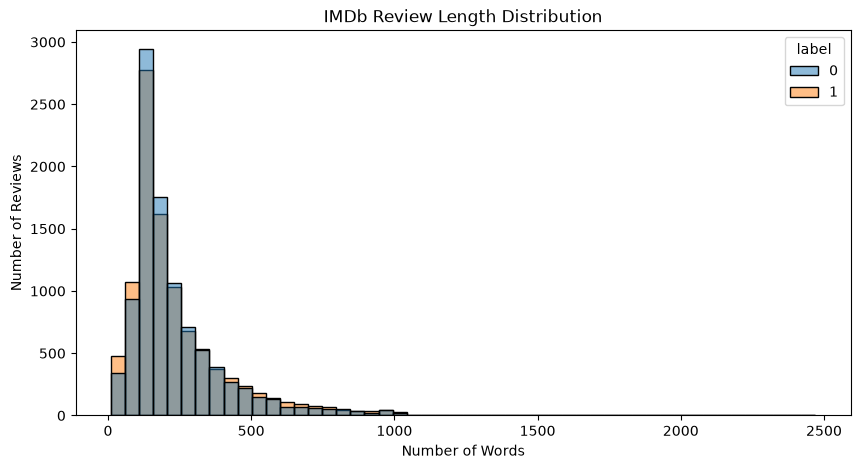


HTML TAG ANALYSIS
Reviews containing <br> tags: 11700
Percentage: 59.02 %


In [28]:
# ==========================================
# Review Length & HTML Tag Analysis
# ==========================================

# Calculate word counts
train_clean_df["word_count"] = (
    train_clean_df["text"].str.split().str.len()
)

val_df["word_count"] = (
    val_df["text"].str.split().str.len()
)

test_df["word_count"] = (
    test_df["text"].str.split().str.len()
)

# ------------------------------------------
# Overall review length statistics
# ------------------------------------------

print("=" * 60)
print("OVERALL REVIEW LENGTH STATISTICS")
print("=" * 60)

print(train_clean_df["word_count"].describe())


# ------------------------------------------
# Review length by sentiment
# ------------------------------------------

print("\n" + "=" * 60)
print("REVIEW LENGTH BY SENTIMENT")
print("=" * 60)

print(
    train_clean_df.groupby("label")["word_count"].describe()
)


# ------------------------------------------
# Distribution plot
# ------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(
    data=train_clean_df,
    x="word_count",
    hue="label",
    bins=50
)

plt.title("IMDb Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.show()


# ------------------------------------------
# HTML <br> tag analysis
# ------------------------------------------

br_count = train_clean_df["text"].str.contains(
    "<br",
    regex=False
).sum()

br_percentage = (
    br_count / len(train_clean_df)
) * 100

print("\n" + "=" * 60)
print("HTML TAG ANALYSIS")
print("=" * 60)

print("Reviews containing <br> tags:", br_count)
print("Percentage:", round(br_percentage, 2), "%")

In [27]:
train_reviews = set(train_clean_df["text"])
val_reviews = set(val_df["text"])
test_reviews = set(test_df["text"])

print("Train-Test overlap:", len(train_reviews & test_reviews))
print("Validation-Test overlap:", len(val_reviews & test_reviews))
print("Train-Validation overlap:", len(train_reviews & val_reviews))

Train-Test overlap: 0
Validation-Test overlap: 0
Train-Validation overlap: 0


In [26]:
from sklearn.model_selection import train_test_split

train_clean_df, val_df = train_test_split(
    clean_train_pool,
    test_size=0.20,
    random_state=SEED,
    stratify=clean_train_pool["label"]
)

print("Training samples:", len(train_clean_df))
print("Validation samples:", len(val_df))
print("Official test samples:", len(test_df))

Training samples: 19824
Validation samples: 4957
Official test samples: 25000


In [25]:
print(
    "Remaining duplicate reviews:",
    clean_train_pool["text"].duplicated().sum()
)

print(
    "Overlap with test:",
    len(set(clean_train_pool["text"]).intersection(test_review_set))
)

Remaining duplicate reviews: 0
Overlap with test: 0


In [24]:
clean_train_pool = leakage_free_train.drop_duplicates(
    subset="text",
    keep="first"
).copy()

print("Before removing internal duplicates:", len(leakage_free_train))
print("After removing internal duplicates:", len(clean_train_pool))
print(
    "Duplicates removed:",
    len(leakage_free_train) - len(clean_train_pool)
)

Before removing internal duplicates: 24877
After removing internal duplicates: 24781
Duplicates removed: 96


In [23]:
leakage_free_train = train_df[
    ~train_df["text"].isin(test_review_set)
].copy()

print("Original training rows:", len(train_df))
print("Training rows after removing test overlaps:", len(leakage_free_train))

Original training rows: 25000
Training rows after removing test overlaps: 24877


In [22]:
test_review_set = set(test_df["text"])

print("Unique test reviews:", len(test_review_set))

Unique test reviews: 24801


In [21]:
print("Test rows:", len(test_df))
print("Unique test reviews:", test_df["text"].nunique())
print("Duplicate test rows:", test_df["text"].duplicated().sum())

Test rows: 25000
Unique test reviews: 24801
Duplicate test rows: 199


In [20]:
print("Original training rows:", len(train_df))
print("Unique training reviews:", train_df["text"].nunique())
print("Duplicate training rows:", train_df["text"].duplicated().sum())

Original training rows: 25000
Unique training reviews: 24904
Duplicate training rows: 96


In [19]:
train_test_overlap = set(train_clean_df["text"]).intersection(
    set(test_df["text"])
)

val_test_overlap = set(val_df["text"]).intersection(
    set(test_df["text"])
)

train_val_overlap = set(train_clean_df["text"]).intersection(
    set(val_df["text"])
)

print("Train-Test overlap:", len(train_test_overlap))
print("Validation-Test overlap:", len(val_test_overlap))
print("Train-Validation overlap:", len(train_val_overlap))

Train-Test overlap: 0
Validation-Test overlap: 0
Train-Validation overlap: 41


In [18]:
print("Training distribution:")
print(train_clean_df["label"].value_counts(normalize=True) * 100)

print("\nValidation distribution:")
print(val_df["label"].value_counts(normalize=True) * 100)

print("\nTest distribution:")
print(test_df["label"].value_counts(normalize=True) * 100)

Training distribution:
label
1    50.133159
0    49.866841
Name: proportion, dtype: float64

Validation distribution:
label
1    50.140675
0    49.859325
Name: proportion, dtype: float64

Test distribution:
label
0    50.0
1    50.0
Name: proportion, dtype: float64


In [17]:
from sklearn.model_selection import train_test_split

train_clean_df, val_df = train_test_split(
    clean_train_df,
    test_size=0.20,
    random_state=SEED,
    stratify=clean_train_df["label"]
)

print("Training samples:", len(train_clean_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

Training samples: 19901
Validation samples: 4976
Test samples: 25000


In [16]:
# Remove reviews that appear in both the original train and test sets

leakage_texts = set(cross_split_df["text"])

clean_train_df = train_df[
    ~train_df["text"].isin(leakage_texts)
].copy()

print("Original training samples:", len(train_df))
print("Removed leakage duplicates:", len(leakage_texts))
print("Clean training samples:", len(clean_train_df))

Original training samples: 25000
Removed leakage duplicates: 123
Clean training samples: 24877


In [15]:
cross_split_df["label"].value_counts(normalize=True) * 100

label
0    77.235772
1    22.764228
Name: proportion, dtype: float64

In [14]:
cross_split_df[["label", "test_label"]].value_counts()

label  test_label
0      0             95
1      1             28
Name: count, dtype: int64

In [13]:
# Create a mapping from review text to labels in the test set
test_label_map = dict(zip(test_df["text"], test_df["label"]))

# Find reviews that occur in both train and test
cross_split_df = train_df[
    train_df["text"].isin(test_label_map)
][["text", "label"]].copy()

cross_split_df["test_label"] = cross_split_df["text"].map(test_label_map)

# Check whether labels agree
cross_split_df["same_label"] = (
    cross_split_df["label"] == cross_split_df["test_label"]
)

print("Cross-split duplicate reviews:", len(cross_split_df))
print("\nLabel agreement:")
print(cross_split_df["same_label"].value_counts())

print("\nLabel conflicts:")
print((~cross_split_df["same_label"]).sum())

Cross-split duplicate reviews: 123

Label agreement:
same_label
True    123
Name: count, dtype: int64

Label conflicts:
0


In [12]:
train_reviews = set(train_df["text"])
test_reviews = set(test_df["text"])

cross_split_duplicates = train_reviews.intersection(test_reviews)

print("Reviews appearing in both train and test:",
      len(cross_split_duplicates))

Reviews appearing in both train and test: 123


In [11]:
print("Duplicate reviews in training set:", train_df["text"].duplicated().sum())
print("Duplicate reviews in test set:", test_df["text"].duplicated().sum())

Duplicate reviews in training set: 96
Duplicate reviews in test set: 199


In [10]:
print("Missing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in test data:")
print(test_df.isnull().sum())

Missing values in training data:
text     0
label    0
dtype: int64

Missing values in test data:
text     0
label    0
dtype: int64


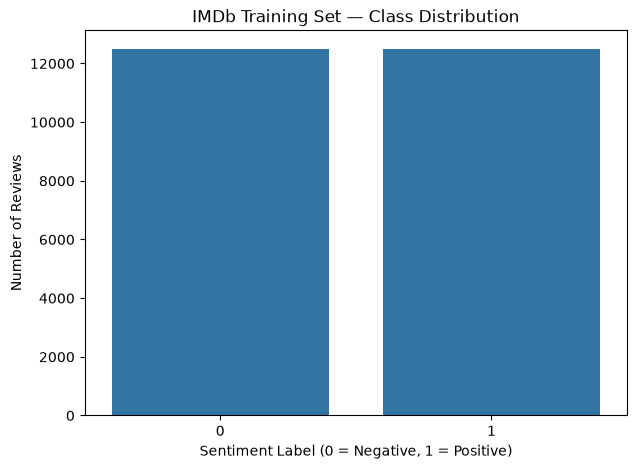

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(data=train_df, x="label")

plt.title("IMDb Training Set — Class Distribution")
plt.xlabel("Sentiment Label (0 = Negative, 1 = Positive)")
plt.ylabel("Number of Reviews")
plt.show()

In [8]:
print("Label counts:")
print(train_df["label"].value_counts())

print("\nLabel percentages:")
print(train_df["label"].value_counts(normalize=True) * 100)

Label counts:
label
0    12500
1    12500
Name: count, dtype: int64

Label percentages:
label
0    50.0
1    50.0
Name: proportion, dtype: float64


In [7]:
train_df.sample(3, random_state=SEED)

,text,label
6868,"Dumb is as dumb does, in this thoroughly unint...",0
24016,I dug out from my garage some old musicals and...,1
9668,After watching this movie I was honestly disap...,0


In [6]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 32.0 MB


In [5]:
train_df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [4]:
train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (25000, 2)
Test shape: (25000, 2)


In [3]:
print("Training samples:", len(dataset["train"]))
print("Test samples:", len(dataset["test"]))
print("Unsupervised samples:", len(dataset["unsupervised"]))

Training samples: 25000
Test samples: 25000
Unsupervised samples: 50000


In [2]:
dataset = load_dataset("stanfordnlp/imdb")

dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [1]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42

print("Libraries imported successfully.")



Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully.


# IMDb Sentiment Classification — Exploratory Data Analysis

This notebook explores the IMDb Large Movie Review Dataset before model training.

### Objectives
- Understand the dataset structure
- Inspect class distribution
- Check missing and duplicate reviews
- Analyze review length
- Prepare a reproducible train/validation/test split